# 公式 o8 — Glycolysis Model and Metabolic Control Analysis

> **出典（E-Cell4 公式）**: Examples / example05 — https://ecell4.e-cell.org/examples/example05.html
>
> 解糖系のエネルギー代謝（ATP/ADP/AMP と中間体）の ODE モデル＋**代謝制御解析(MCA)**。
> 反応部分は公式コードをそのまま実行。MCA 部分は下記の互換性注記を参照。

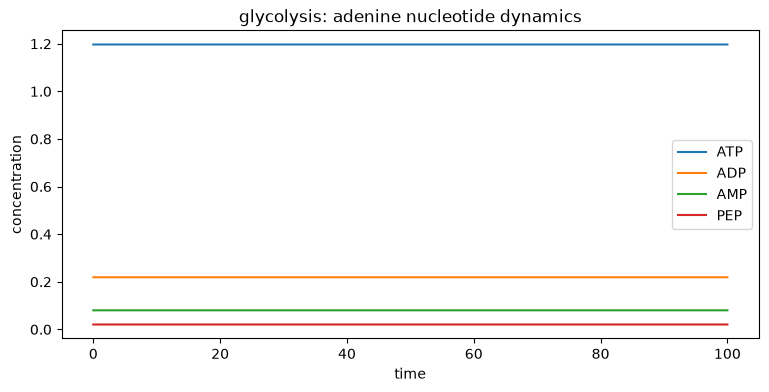

steady-ish ATP=1.197 ADP=0.219 AMP=0.080


In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

with reaction_rules():
    2 * ATP > 2 * A13P2G + 2 * ADP | (3.2 * ATP / (1.0 + (ATP / 1.0) ** 4.0))
    A13P2G > A23P2G | 1500
    A23P2G > PEP | 0.15
    A13P2G + ADP > PEP + ATP | 1.57e+4
    PEP + ADP > ATP | 559
    AMP + ATP > 2 * ADP | 1.0 * AMP * ATP
    2 * ADP > AMP + ATP | 2.0 * ADP * ADP
    ATP > ADP | 1.46
m = get_model()
y0 = {'A13P2G': 0.0005082, 'A23P2G': 5.0834, 'PEP': 0.020502, 'AMP': 0.080139, 'ADP': 0.2190, 'ATP': 1.196867}
a = run_simulation(100, ndiv=500, model=m, y0=y0, species_list=['ATP','ADP','AMP','PEP']).as_array()

fig, ax = plt.subplots(figsize=(9, 4))
for i, lab in enumerate(['ATP','ADP','AMP','PEP'], 1):
    ax.plot(a[:,0], a[:,i], label=lab)
ax.set_xlabel('time'); ax.set_ylabel('concentration'); ax.set_title('glycolysis: adenine nucleotide dynamics'); ax.legend()
plt.show()
print('steady-ish ATP=%.3f ADP=%.3f AMP=%.3f' % (a[-1,1], a[-1,2], a[-1,3]))

## 読み取り（ダイナミクス）

ATP・ADP・AMP と解糖中間体が相互変換しながら定常（または振動）へ向かう。ホスホフルクトキナーゼ相当の
最初の反応が ATP による負のフィードバック（`3.2*ATP/(1+(ATP)**4)`）を持ち、エネルギー恒常性を作る。

## 代謝制御解析（MCA）— 公式コードと互換性注記

公式例題は続けて **MCA**（各反応が定常フラックス/濃度をどれだけ支配するかの制御係数）を計算する。
そのコードは以下（出典のまま）:

```python
import numpy as np
w = ret.world
sim = ode.Simulator(w, m)
x = np.array(sim.values());  v = np.array(sim.fluxes())
S = np.array(sim.stoichiometry());  E = np.array(sim.elasticity())
from ecell4.mca import generate_full_rank_matrix, scaled_control_coefficients
ccc, fcc = scaled_control_coefficients(S, E, v, x)   # 濃度制御係数, フラックス制御係数
```

> **互換性注記（本ノートで非実行）**: 本環境の `ecell4.mca` は NumPy 1.x 前提で書かれており、
> インストール済みの **NumPy 2.5 とは非互換**（`np.float` 削除・`numpy.lib.twodim_base` の private 化）。
> そのため MCA セルはここでは実行していない（反応ダイナミクスの部分は上で実行済み）。
> MCA を動かすには NumPy<2 の別環境か、`ecell4.mca` の NumPy2 対応が必要。
> `sim.stoichiometry()/elasticity()/fluxes()/values()` 自体は動くので、MCA の線形代数を自前で書くことも可能。